In [1]:
import matplotlib.pyplot as plt
import os
import xarray as xr
import pandas as pd
import numpy as np
import copy
from datetime import datetime, timedelta
from scipy.interpolate import interp1d
import sys
sys.path.append(os.path.expanduser('/home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4'))


%load_ext autoreload
%autoreload 1
%aimport get_manobs_soundings_pr_df
%aimport parsivel_functions_margaux
%aimport MetData_functions_margaux
%aimport fonctions1

grav = 9.81

/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/wintre-mix_fzra_and_pl/soundings_functions.py:185: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/wintre-mix_fzra_and_pl/kin1d_functions.py:508: SyntaxWarning: invalid escape sequence '\s'
  temp_prof = pd.read_csv(path_wintremi_soundings+'IOP'+str(IOP_number).zfill(2)+'/master/'+list_s[sounding_number],skiprows=[1,2],header=0, encoding='ISO-8859-1',sep='\s+')


In [ ]:

df_manobs = pd.read_csv('df_all_events_tw_29juillet2026.csv')
df_manobs_temp = pd.read_csv('df_all_events_temp_29juillet2026.csv')

df_manobs = df_manobs.drop_duplicates(subset=['rounded_time','site_for_title'], keep='first')
df_manobs_temp = df_manobs_temp.drop_duplicates(subset=['rounded_time','site_for_title'], keep='first')

df_manobs      = df_manobs[df_manobs.Sounding==True] 
df_manobs_temp = df_manobs_temp[df_manobs_temp.Sounding==True] 

# Figure 5

In [3]:

def annotate_5_points(ax,df_manobs):

    rows_to_annotate = [
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA and PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 10)].iloc[2],
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA and PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 10)].iloc[3],
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA and PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 10)].iloc[0],
        df_manobs[(df_manobs['manobs_with_mix'] == 'PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 150)].iloc[0],
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA and PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 10)].iloc[1],
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA') & (df_manobs['WL_integral']*grav/273.15 < 50)],        
    ]
    labels = ['1','2','3','4','5','6']
    for row, label in zip(rows_to_annotate, labels):

        x = row['WL_integral'] * grav / 273.15
        y = -row['CL_integral'] * grav / 273.15
        ax.annotate(label, (x, y), textcoords="offset points", xytext=(4.,0.), ha='left',va='center', fontsize=10)

    return ax
    

/tmp/rml000/2653800/ipykernel_3058083/3627024062.py:53: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax[1,0].scatter(to_plot_pl['WL_integral']*grav/273.15,-to_plot_pl['CL_integral']*grav/273.15, edgecolors=color_list['PL'],label='PL',marker='o',facecolor='none',c=to_plot_pl.pr,cmap=cmap,vmin=0,vmax=5)
/tmp/rml000/2653800/ipykernel_3058083/3627024062.py:56: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax[1,0].scatter(to_plot_pl_fzra['WL_integral']*grav/273.15,-to_plot_pl_fzra['CL_integral']*grav/273.15, edgecolors=color_list['FZRA and PL'],label='FZRA and PL',marker='s',facecolor='none',c=to_plot_pl_fzra.pr,cmap=cmap,vmin=0,vmax=5)
/tmp/rml000/2653800/ipykernel_3058083/3627024062.py:59: UserWarning: You passed both c and facecolor/facecolors for the markers. c ha

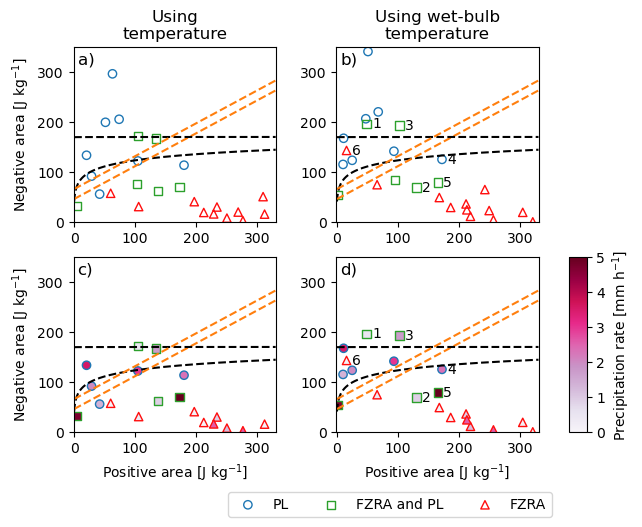

In [5]:

grav = 9.81
color_list = {'No precip.':'grey','PL':'#1f77b4','FZRA':"#ff0e0e",'FZRA and PL':'#2ca02c'}

fig,ax = plt.subplots(2,2,figsize=(6,5))

PA = np.linspace(0,330,1000)



to_plot_pl = df_manobs_temp[df_manobs_temp['manobs_with_mix'] == 'PL']
ax[0,0].scatter(to_plot_pl['WL_integral']*grav/273.15,-to_plot_pl['CL_integral']*grav/273.15, color=color_list['PL'],label='PL',marker='o',facecolor='none')

to_plot_pl_fzra = df_manobs_temp[df_manobs_temp['manobs_with_mix'] == 'FZRA and PL']
ax[0,0].scatter(to_plot_pl_fzra['WL_integral']*grav/273.15,-to_plot_pl_fzra['CL_integral']*grav/273.15, color=color_list['FZRA and PL'],label='FZRA and PL',marker='s',facecolor='none')

to_plot_fzra = df_manobs_temp[df_manobs_temp['manobs_with_mix'] == 'FZRA']
ax[0,0].scatter(to_plot_fzra['WL_integral']*grav/273.15,-to_plot_fzra['CL_integral']*grav/273.15, color=color_list['FZRA'],label='FZRA',marker='^',facecolor='none')

# ax[0,0].set_xlabel('Positive area [J kg$^{-1}$]')
ax[0,0].set_ylabel('Negative area [J kg$^{-1}$]')

to_plot_pl = df_manobs[df_manobs['manobs_with_mix'] == 'PL']
ax[0,1].scatter(to_plot_pl['WL_integral']*grav/273.15,-to_plot_pl['CL_integral']*grav/273.15, color=color_list['PL'],label='PL',marker='o',facecolor='none')

to_plot_pl_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA and PL']
ax[0,1].scatter(to_plot_pl_fzra['WL_integral']*grav/273.15,-to_plot_pl_fzra['CL_integral']*grav/273.15, color=color_list['FZRA and PL'],label='FZRA and PL',marker='s',facecolor='none')

to_plot_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA']
ax[0,1].scatter(to_plot_fzra['WL_integral']*grav/273.15,-to_plot_fzra['CL_integral']*grav/273.15, color=color_list['FZRA'],label='FZRA',marker='^',facecolor='none')


# ax[0,1].set_xlabel('Positive area [J kg$^{-1}$]')
# ax[0,1].set_ylabel('Negative area [J kg$^{-1}$]')



for i in range(2):
    ax[0,i].set_ylim([-1,350])
    ax[0,i].set_xlim([-1,330])

ax[0,1].legend(loc='upper right',bbox_to_anchor=(1.1,-1.5), ncol=3)

ax[0,0].set_title('Using\ntemperature')
ax[0,1].set_title('Using wet-bulb\ntemperature')

ax[0,0].text(0.02, 0.97, 'a)', transform=ax[0,0].transAxes, fontsize=12, va='top')
ax[0,1].text(0.02, 0.97, 'b)', transform=ax[0,1].transAxes, fontsize=12, va='top')


cmap ='PuRd'

to_plot_pl = df_manobs_temp[df_manobs_temp['manobs_with_mix'] == 'PL']
ax[1,0].scatter(to_plot_pl['WL_integral']*grav/273.15,-to_plot_pl['CL_integral']*grav/273.15, edgecolors=color_list['PL'],label='PL',marker='o',facecolor='none',c=to_plot_pl.pr,cmap=cmap,vmin=0,vmax=5)

to_plot_pl_fzra = df_manobs_temp[df_manobs_temp['manobs_with_mix'] == 'FZRA and PL']
ax[1,0].scatter(to_plot_pl_fzra['WL_integral']*grav/273.15,-to_plot_pl_fzra['CL_integral']*grav/273.15, edgecolors=color_list['FZRA and PL'],label='FZRA and PL',marker='s',facecolor='none',c=to_plot_pl_fzra.pr,cmap=cmap,vmin=0,vmax=5)

to_plot_fzra = df_manobs_temp[df_manobs_temp['manobs_with_mix'] == 'FZRA']
ax[1,0].scatter(to_plot_fzra['WL_integral']*grav/273.15,-to_plot_fzra['CL_integral']*grav/273.15, edgecolors=color_list['FZRA'],label='FZRA',marker='^',facecolor='none',c=to_plot_fzra.pr,cmap=cmap,vmin=0,vmax=5)

ax[1,0].set_xlabel('Positive area [J kg$^{-1}$]')
ax[1,0].set_ylabel('Negative area [J kg$^{-1}$]')

to_plot_pl = df_manobs[df_manobs['manobs_with_mix'] == 'PL']
ax[1,1].scatter(to_plot_pl['WL_integral']*grav/273.15,-to_plot_pl['CL_integral']*grav/273.15, edgecolors=color_list['PL'],label='PL',marker='o',facecolor='none',c=to_plot_pl.pr,cmap=cmap,vmin=0,vmax=5)

to_plot_pl_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA and PL']
ax[1,1].scatter(to_plot_pl_fzra['WL_integral']*grav/273.15,-to_plot_pl_fzra['CL_integral']*grav/273.15, edgecolors=color_list['FZRA and PL'],label='FZRA and PL',marker='s',facecolor='none',c=to_plot_pl_fzra.pr,cmap=cmap,vmin=0,vmax=5)

to_plot_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA']
sc = ax[1,1].scatter(to_plot_fzra['WL_integral']*grav/273.15,-to_plot_fzra['CL_integral']*grav/273.15, edgecolors=color_list['FZRA'],label='FZRA',marker='^',facecolor='none',c=to_plot_fzra.pr,cmap=cmap,vmin=0,vmax=5)

cbar_ax = fig.add_axes([0.95, 0.11, 0.03, 0.35])
plt.colorbar(sc,ax=ax,cax=cbar_ax,label=r'Precipitation rate [mm h$^{-1}$]')

PA = np.linspace(0,330,1000)


for i in range(2):
    for j in range(2):
        ax[i,j].plot(PA,41+17.9*np.log(PA+1),label='Birk et al. (2020)',linestyle='--',color='k')
        ax[i,j].plot(PA,46+0.66*PA,label='Bourgoin (2000)',linestyle='--',color='C1')
        ax[i,j].plot(PA,170+0.08*np.log(PA+1),linestyle='--',color='k')
        ax[i,j].plot(PA,66+0.66*PA,linestyle='--',color='C1')

ax[1,1].set_xlabel('Positive area [J kg$^{-1}$]')
# ax[1].set_ylabel('Negative area [J kg$^{-1}$]')

for i in range(2):
    ax[1,i].set_ylim([-1,350])
    ax[1,i].set_xlim([-1,330])

# ax[1,1].legend(loc='upper right',bbox_to_anchor=(1.1,-0.3), ncol=3)

ax[1,0].text(0.02, 0.97, 'c)', transform=ax[1,0].transAxes, fontsize=12, va='top')
ax[1,1].text(0.02, 0.97, 'd)', transform=ax[1,1].transAxes, fontsize=12, va='top')

ax[0,1] = annotate_5_points(ax[0,1], df_manobs)
ax[1,1] = annotate_5_points(ax[1,1], df_manobs)

plt.subplots_adjust(wspace=0.3)


# plt.savefig('figures/Zerr-like_4panels.png',format='png',dpi=200,bbox_inches='tight')

# Score tables

In [7]:
'''Computed scores for predictions'''

df_manobs_to_score = df_manobs[(df_manobs['manobs_with_mix'] == 'PL')   |\
                                    (df_manobs['manobs_with_mix'] == 'FZRA') |\
                                    (df_manobs['manobs_with_mix'] == 'FZRA and PL') &\
                                     ((df_manobs['WL_integral']>0.) & (df_manobs['CL_integral']<0.) )]

df_manobs_to_score.loc[:,'PA'] = df_manobs_to_score['WL_integral']*grav/273.15
df_manobs_to_score.loc[:,'NA'] = -df_manobs_to_score['CL_integral']*grav/273.15

df_manobs_to_score.loc[:,'predicted_PL_birk'] = df_manobs_to_score['NA']   > 170+0.08*np.log(df_manobs_to_score['PA']+1)
df_manobs_to_score.loc[:,'predicted_FZRA_birk'] = df_manobs_to_score['NA'] < 41+17.9*np.log(df_manobs_to_score['PA']+1)
df_manobs_to_score.loc[:,'predicted_FZRAPL_birk'] = (df_manobs_to_score['NA'] > 41+17.9*np.log(df_manobs_to_score['PA']+1)) & (df_manobs_to_score['NA'] < 170+0.08*np.log(df_manobs_to_score['PA']+1))

df_manobs_to_score.loc[:,'predicted_PL_bourgouin'] = df_manobs_to_score['NA']   > 66+0.66*df_manobs_to_score['PA']
df_manobs_to_score.loc[:,'predicted_FZRA_bourgouin'] = df_manobs_to_score['NA'] < 46+0.46*df_manobs_to_score['PA']
df_manobs_to_score.loc[:,'predicted_FZRAPL_bourgouin'] = (df_manobs_to_score['NA'] > 46+0.66*df_manobs_to_score['PA']) & (df_manobs_to_score['NA'] < 170+0.08*np.log(df_manobs_to_score['PA']+1))



PL_hit_rate_birk = ((df_manobs_to_score['predicted_PL_birk'] == True) & (df_manobs_to_score['manobs_with_mix'] == 'PL')).sum()
PL_hit_rate_bourgouin = ((df_manobs_to_score['predicted_PL_bourgouin'] == True) & (df_manobs_to_score['manobs_with_mix'] == 'PL')).sum()

FZRA_hit_rate_birk = ((df_manobs_to_score['predicted_FZRA_birk'] == True) & (df_manobs_to_score['manobs_with_mix'] == 'FZRA')).sum()
FZRA_hit_rate_bourgouin = ((df_manobs_to_score['predicted_FZRA_bourgouin'] == True) & (df_manobs_to_score['manobs_with_mix'] == 'FZRA')).sum()

FZRAPL_hit_rate_birk = ((df_manobs_to_score['predicted_FZRAPL_birk'] == True) & (df_manobs_to_score['manobs_with_mix'] == 'FZRA and PL')).sum()
FZRAPL_hit_rate_bourgouin = ((df_manobs_to_score['predicted_FZRAPL_bourgouin'] == True) & (df_manobs_to_score['manobs_with_mix'] == 'FZRA and PL')).sum()


PL_false_alarm_rate_birk = ((df_manobs_to_score['predicted_PL_birk'] == True) & (df_manobs_to_score['manobs_with_mix'] != 'PL')).sum()
PL_false_alarm_rate_bourgouin = ((df_manobs_to_score['predicted_PL_bourgouin'] == True) & (df_manobs_to_score['manobs_with_mix'] != 'PL')).sum()

FZRA_false_alarm_rate_birk = ((df_manobs_to_score['predicted_FZRA_birk'] == True) & (df_manobs_to_score['manobs_with_mix'] != 'FZRA')).sum()
FZRA_false_alarm_rate_bourgouin = ((df_manobs_to_score['predicted_FZRA_bourgouin'] == True) & (df_manobs_to_score['manobs_with_mix'] != 'FZRA')).sum()

FZRAPL_false_alarm_rate_birk = ((df_manobs_to_score['predicted_FZRAPL_birk'] == True) & (df_manobs_to_score['manobs_with_mix'] != 'FZRA and PL')).sum()
FZRAPL_false_alarm_rate_bourgouin = ((df_manobs_to_score['predicted_FZRAPL_bourgouin'] == True) & (df_manobs_to_score['manobs_with_mix'] != 'FZRA and PL')).sum()


PL_misses_rate_birk = ((df_manobs_to_score['predicted_PL_birk'] == False) & (df_manobs_to_score['manobs_with_mix'] == 'PL')).sum()
PL_misses_rate_bourgouin = ((df_manobs_to_score['predicted_PL_bourgouin'] == False) & (df_manobs_to_score['manobs_with_mix'] == 'PL')).sum()

FZRA_misses_rate_birk = ((df_manobs_to_score['predicted_FZRA_birk'] == False) & (df_manobs_to_score['manobs_with_mix'] == 'FZRA')).sum()
FZRA_misses_rate_bourgouin = ((df_manobs_to_score['predicted_FZRA_bourgouin'] == False) & (df_manobs_to_score['manobs_with_mix'] == 'FZRA')).sum()

FZRAPL_misses_rate_birk = ((df_manobs_to_score['predicted_FZRAPL_birk'] == False) & (df_manobs_to_score['manobs_with_mix'] == 'FZRA and PL')).sum()
FZRAPL_misses_rate_bourgouin = ((df_manobs_to_score['predicted_FZRAPL_bourgouin'] == False) & (df_manobs_to_score['manobs_with_mix'] == 'FZRA and PL')).sum()

PL_CSI_birk = PL_hit_rate_birk / (PL_hit_rate_birk + PL_false_alarm_rate_birk + PL_misses_rate_birk)
PL_CSI_bourgouin = PL_hit_rate_bourgouin / (PL_hit_rate_bourgouin + PL_false_alarm_rate_bourgouin + PL_misses_rate_bourgouin)
FZRA_CSI_birk = FZRA_hit_rate_birk / (FZRA_hit_rate_birk + FZRA_false_alarm_rate_birk + FZRA_misses_rate_birk)
FZRA_CSI_bourgouin = FZRA_hit_rate_bourgouin / (FZRA_hit_rate_bourgouin + FZRA_false_alarm_rate_bourgouin + FZRA_misses_rate_bourgouin)
FZRAPL_CSI_birk = FZRAPL_hit_rate_birk / (FZRAPL_hit_rate_birk + FZRAPL_false_alarm_rate_birk + FZRAPL_misses_rate_birk)
FZRAPL_CSI_bourgouin = FZRAPL_hit_rate_bourgouin / (FZRAPL_hit_rate_bourgouin + FZRAPL_false_alarm_rate_bourgouin + FZRAPL_misses_rate_bourgouin)

PL_POD_birk = PL_hit_rate_birk / (PL_hit_rate_birk + PL_misses_rate_birk)
PL_POD_bourgouin = PL_hit_rate_bourgouin / (PL_hit_rate_bourgouin + PL_misses_rate_bourgouin)
FZRA_POD_birk = FZRA_hit_rate_birk / (FZRA_hit_rate_birk + FZRA_misses_rate_birk)
FZRA_POD_bourgouin = FZRA_hit_rate_bourgouin / (FZRA_hit_rate_bourgouin + FZRA_misses_rate_bourgouin)
FZRAPL_POD_birk = FZRAPL_hit_rate_birk / (FZRAPL_hit_rate_birk + FZRAPL_misses_rate_birk)
FZRAPL_POD_bourgouin = FZRAPL_hit_rate_bourgouin / (FZRAPL_hit_rate_bourgouin + FZRAPL_misses_rate_bourgouin)

PL_SR_birk = 1.-PL_false_alarm_rate_birk / (PL_hit_rate_birk + PL_false_alarm_rate_birk)
PL_SR_bourgouin = 1.-PL_false_alarm_rate_bourgouin / (PL_hit_rate_bourgouin + PL_false_alarm_rate_bourgouin)
FZRA_SR_birk = 1.-FZRA_false_alarm_rate_birk / (FZRA_hit_rate_birk + FZRA_false_alarm_rate_birk)
FZRA_SR_bourgouin = 1.-FZRA_false_alarm_rate_bourgouin / (FZRA_hit_rate_bourgouin + FZRA_false_alarm_rate_bourgouin)
FZRAPL_SR_birk = 1.-FZRAPL_false_alarm_rate_birk / (FZRAPL_hit_rate_birk + FZRAPL_false_alarm_rate_birk)
FZRAPL_SR_bourgouin = 1.-FZRAPL_false_alarm_rate_bourgouin / (FZRAPL_hit_rate_bourgouin + FZRAPL_false_alarm_rate_bourgouin)





'''With dry bulb temperature'''


df_manobs_to_score_T = df_manobs_temp[((df_manobs_temp['manobs_with_mix'] == 'PL')   |\
                                    (df_manobs_temp['manobs_with_mix'] == 'FZRA') |\
                                    (df_manobs_temp['manobs_with_mix'] == 'FZRA and PL'))  &\
                                     ((df_manobs_temp['WL_integral']>0.) & (df_manobs_temp['CL_integral']<0.) )]

df_manobs_to_score_T.loc[:,'PA'] = df_manobs_to_score_T['WL_integral']*grav/273.15
df_manobs_to_score_T.loc[:,'NA'] = -df_manobs_to_score_T['CL_integral']*grav/273.15


df_manobs_to_score_T.loc[:,'predicted_PL_birk'] = df_manobs_to_score_T['NA']   > 170+0.08*np.log(df_manobs_to_score_T['PA']+1)
df_manobs_to_score_T.loc[:,'predicted_FZRA_birk'] = df_manobs_to_score_T['NA'] < 41+17.9*np.log(df_manobs_to_score_T['PA']+1)
df_manobs_to_score_T.loc[:,'predicted_FZRAPL_birk'] = (df_manobs_to_score_T['NA'] > 41+17.9*np.log(df_manobs_to_score_T['PA']+1)) & (df_manobs_to_score_T['NA'] < 170+0.08*np.log(df_manobs_to_score_T['PA']+1))

df_manobs_to_score_T.loc[:,'predicted_PL_bourgouin'] = df_manobs_to_score_T['NA']   > 66+0.66*df_manobs_to_score_T['PA']
df_manobs_to_score_T.loc[:,'predicted_FZRA_bourgouin'] = df_manobs_to_score_T['NA'] < 46+0.46*df_manobs_to_score_T['PA']
df_manobs_to_score_T.loc[:,'predicted_FZRAPL_bourgouin'] = (df_manobs_to_score_T['NA'] > 46+0.66*df_manobs_to_score_T['PA']) & (df_manobs_to_score_T['NA'] < 170+0.08*np.log(df_manobs_to_score_T['PA']+1))


PL_hit_rate_birk_T = ((df_manobs_to_score_T['predicted_PL_birk'] == True) & (df_manobs_to_score_T['manobs_with_mix'] == 'PL')).sum()
PL_hit_rate_bourgouin_T = ((df_manobs_to_score_T['predicted_PL_bourgouin'] == True) & (df_manobs_to_score_T['manobs_with_mix'] == 'PL')).sum()

FZRA_hit_rate_birk_T = ((df_manobs_to_score_T['predicted_FZRA_birk'] == True) & (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA')).sum()
FZRA_hit_rate_bourgouin_T = ((df_manobs_to_score_T['predicted_FZRA_bourgouin'] == True) & (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA')).sum()

FZRAPL_hit_rate_birk_T = ((df_manobs_to_score_T['predicted_FZRAPL_birk'] == True) & (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA and PL')).sum()
FZRAPL_hit_rate_bourgouin_T = ((df_manobs_to_score_T['predicted_FZRAPL_bourgouin'] == True) & (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA and PL')).sum()

PL_false_alarm_rate_birk_T = ((df_manobs_to_score_T['predicted_PL_birk'] == True) & (df_manobs_to_score_T['manobs_with_mix'] != 'PL')).sum()
PL_false_alarm_rate_bourgouin_T = ((df_manobs_to_score_T['predicted_PL_bourgouin'] == True) & (df_manobs_to_score_T['manobs_with_mix'] != 'PL')).sum()

FZRA_false_alarm_rate_birk_T = ((df_manobs_to_score_T['predicted_FZRA_birk'] == True) & (df_manobs_to_score_T['manobs_with_mix'] != 'FZRA')).sum()
FZRA_false_alarm_rate_bourgouin_T = ((df_manobs_to_score_T['predicted_FZRA_bourgouin'] == True) & (df_manobs_to_score_T['manobs_with_mix'] != 'FZRA')).sum()

FZRAPL_false_alarm_rate_birk_T = ((df_manobs_to_score_T['predicted_FZRAPL_birk'] == True) & (df_manobs_to_score_T['manobs_with_mix'] != 'FZRA and PL')).sum()
FZRAPL_false_alarm_rate_bourgouin_T = ((df_manobs_to_score_T['predicted_FZRAPL_bourgouin'] == True) & (df_manobs_to_score_T['manobs_with_mix'] != 'FZRA and PL')).sum()

PL_misses_rate_birk_T = ((df_manobs_to_score_T['predicted_PL_birk'] == False) & (df_manobs_to_score_T['manobs_with_mix'] == 'PL')).sum()
PL_misses_rate_bourgouin_T = ((df_manobs_to_score_T['predicted_PL_bourgouin'] == False) & (df_manobs_to_score_T['manobs_with_mix'] == 'PL')).sum()

FZRA_misses_rate_birk_T = ((df_manobs_to_score_T['predicted_FZRA_birk'] == False) & (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA')).sum()
FZRA_misses_rate_bourgouin_T = ((df_manobs_to_score_T['predicted_FZRA_bourgouin'] == False) & (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA')).sum()

FZRAPL_misses_rate_birk_T = ((df_manobs_to_score_T['predicted_FZRAPL_birk'] == False) & (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA and PL')).sum()
FZRAPL_misses_rate_bourgouin_T = ((df_manobs_to_score_T['predicted_FZRAPL_bourgouin'] == False) & (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA and PL')).sum()


PL_CSI_birk_T = PL_hit_rate_birk_T / (PL_hit_rate_birk_T + PL_false_alarm_rate_birk_T + PL_misses_rate_birk_T)
PL_CSI_bourgouin_T = PL_hit_rate_bourgouin_T / (PL_hit_rate_bourgouin_T + PL_false_alarm_rate_bourgouin_T + PL_misses_rate_bourgouin_T)
FZRA_CSI_birk_T = FZRA_hit_rate_birk_T / (FZRA_hit_rate_birk_T + FZRA_false_alarm_rate_birk_T + FZRA_misses_rate_birk_T)
FZRA_CSI_bourgouin_T = FZRA_hit_rate_bourgouin_T / (FZRA_hit_rate_bourgouin_T + FZRA_false_alarm_rate_bourgouin_T + FZRA_misses_rate_bourgouin_T)
FZRAPL_CSI_birk_T = FZRAPL_hit_rate_birk_T / (FZRAPL_hit_rate_birk_T + FZRAPL_false_alarm_rate_birk_T + FZRAPL_misses_rate_birk_T)
FZRAPL_CSI_bourgouin_T = FZRAPL_hit_rate_bourgouin_T / (FZRAPL_hit_rate_bourgouin_T + FZRAPL_false_alarm_rate_bourgouin_T + FZRAPL_misses_rate_bourgouin_T)

PL_POD_birk_T = PL_hit_rate_birk_T / (PL_hit_rate_birk_T + PL_misses_rate_birk_T)
PL_POD_bourgouin_T = PL_hit_rate_bourgouin_T / (PL_hit_rate_bourgouin_T + PL_misses_rate_bourgouin_T)
FZRA_POD_birk_T = FZRA_hit_rate_birk_T / (FZRA_hit_rate_birk_T + FZRA_misses_rate_birk_T)
FZRA_POD_bourgouin_T = FZRA_hit_rate_bourgouin_T / (FZRA_hit_rate_bourgouin_T + FZRA_misses_rate_bourgouin_T)
FZRAPL_POD_birk_T = FZRAPL_hit_rate_birk_T / (FZRAPL_hit_rate_birk_T + FZRAPL_misses_rate_birk_T)
FZRAPL_POD_bourgouin_T = FZRAPL_hit_rate_bourgouin_T / (FZRAPL_hit_rate_bourgouin_T + FZRAPL_misses_rate_bourgouin_T)

PL_SR_birk_T = 1.-PL_false_alarm_rate_birk_T / (PL_hit_rate_birk_T + PL_false_alarm_rate_birk_T)
PL_SR_bourgouin_T = 1.-PL_false_alarm_rate_bourgouin_T / (PL_hit_rate_bourgouin_T + PL_false_alarm_rate_bourgouin_T)
FZRA_SR_birk_T = 1.-FZRA_false_alarm_rate_birk_T / (FZRA_hit_rate_birk_T + FZRA_false_alarm_rate_birk_T)
FZRA_SR_bourgouin_T = 1.-FZRA_false_alarm_rate_bourgouin_T / (FZRA_hit_rate_bourgouin_T + FZRA_false_alarm_rate_bourgouin_T)
FZRAPL_SR_birk_T = 1.-FZRAPL_false_alarm_rate_birk_T / (FZRAPL_hit_rate_birk_T + FZRAPL_false_alarm_rate_birk_T)
FZRAPL_SR_bourgouin_T = 1.-FZRAPL_false_alarm_rate_bourgouin_T / (FZRAPL_hit_rate_bourgouin_T + FZRAPL_false_alarm_rate_bourgouin_T)


# Print table with scores
n_PL = (df_manobs_to_score['manobs_with_mix'] == 'PL').sum()
n_FZRA = (df_manobs_to_score['manobs_with_mix'] == 'FZRA').sum()
n_FZRAPL = (df_manobs_to_score['manobs_with_mix'] == 'FZRA and PL').sum()

n_PL_T = (df_manobs_to_score_T['manobs_with_mix'] == 'PL').sum()
n_FZRA_T = (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA').sum()
n_FZRAPL_T = (df_manobs_to_score_T['manobs_with_mix'] == 'FZRA and PL').sum()


rate_cols = ['POD','SR','CSI']

scores_PL = pd.DataFrame({
     'Method': ['Birk Tw', 'Bourgouin Tw', 'Birk T', 'Bourgouin T'],
     'Obs tot': [n_PL, n_PL, n_PL_T, n_PL_T],
     'POD':    [PL_POD_birk,PL_POD_bourgouin,PL_POD_birk_T,PL_POD_bourgouin_T],
     'SR':     [PL_SR_birk,PL_SR_bourgouin,PL_SR_birk_T,PL_SR_bourgouin_T],
     'CSI':    [PL_CSI_birk,PL_CSI_bourgouin,PL_CSI_birk_T,PL_CSI_bourgouin_T],
     })
scores_PL = scores_PL.set_index('Method')
scores_display = scores_PL.copy()
scores_display[rate_cols] = scores_display[rate_cols] * 100
scores_display.style.format({col: "{:.0f}%" for col in rate_cols})
print(scores_display.to_string(float_format=lambda x: f"{x:.0f}%"))

scores_FZRA = pd.DataFrame({
     'Method': ['Birk Tw', 'Bourgouin Tw', 'Birk T', 'Bourgouin T'],
     'Obs tot': [n_FZRA, n_FZRA, n_FZRA_T, n_FZRA_T],
     'POD':    [FZRA_POD_birk,FZRA_POD_bourgouin,FZRA_POD_birk_T,FZRA_POD_bourgouin_T],
     'SR':     [FZRA_SR_birk,FZRA_SR_bourgouin,FZRA_SR_birk_T,FZRA_SR_bourgouin_T],
     'CSI':    [FZRA_CSI_birk,FZRA_CSI_bourgouin,FZRA_CSI_birk_T,FZRA_CSI_bourgouin_T],
     })
scores_FZRA = scores_FZRA.set_index('Method')
scores_display = scores_FZRA.copy()
scores_display[rate_cols] = scores_display[rate_cols] * 100
scores_display.style.format({col: "{:.0f}%" for col in rate_cols})
print(scores_display.to_string(float_format=lambda x: f"{x:.0f}%"))

scores_FZRAPL = pd.DataFrame({
     'Method': ['Birk Tw', 'Bourgouin Tw', 'Birk T', 'Bourgouin T'],
     'Obs tot': [n_FZRAPL, n_FZRAPL, n_FZRAPL_T, n_FZRAPL_T],
     'POD':    [FZRAPL_POD_birk,FZRAPL_POD_bourgouin,FZRAPL_POD_birk_T,FZRAPL_POD_bourgouin_T],
     'SR':     [FZRAPL_SR_birk,FZRAPL_SR_bourgouin,FZRAPL_SR_birk_T,FZRAPL_SR_bourgouin_T],
     'CSI':    [FZRAPL_CSI_birk,FZRAPL_CSI_bourgouin,FZRAPL_CSI_birk_T,FZRAPL_CSI_bourgouin_T],
     })
scores_FZRAPL = scores_FZRAPL.set_index('Method')
scores_display = scores_FZRAPL.copy()
scores_display[rate_cols] = scores_display[rate_cols] * 100
scores_display.style.format({col: "{:.0f}%" for col in rate_cols})
print(scores_display.to_string(float_format=lambda x: f"{x:.0f}%"))






              Obs tot  POD  SR  CSI
Method                             
Birk Tw             9  33% 60%  27%
Bourgouin Tw        9  78% 70%  58%
Birk T              8  38% 75%  33%
Bourgouin T         8  62% 71%  50%
              Obs tot  POD  SR  CSI
Method                             
Birk Tw            12  92% 73%  69%
Bourgouin Tw       12  92% 79%  73%
Birk T             12 100% 60%  60%
Bourgouin T        12 100% 67%  67%
              Obs tot  POD  SR  CSI
Method                             
Birk Tw             6  17% 17%   9%
Bourgouin Tw        6  17% 17%   9%
Birk T              6  17% 50%  14%
Bourgouin T         6  17% 25%  11%


/tmp/rml000/2653800/ipykernel_3058083/3799247932.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_manobs_to_score.loc[:,'PA'] = df_manobs_to_score['WL_integral']*grav/273.15
/tmp/rml000/2653800/ipykernel_3058083/3799247932.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_manobs_to_score.loc[:,'NA'] = -df_manobs_to_score['CL_integral']*grav/273.15
/tmp/rml000/2653800/ipykernel_3058083/3799247932.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

# Figure 12

In [9]:

def annotate_5_points_mintemp(ax,df_manobs):

    rows_to_annotate = [
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA and PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 10)].iloc[2],
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA and PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 10)].iloc[3],
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA and PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 10)].iloc[0],
        df_manobs[(df_manobs['manobs_with_mix'] == 'PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 150)].iloc[0],
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA and PL') & (df_manobs['pr']> 0) & (df_manobs['WL_integral']*grav/273.15 > 10)].iloc[1],
        df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA') & (df_manobs['WL_integral']*grav/273.15 < 50)],        
    ]
    labels = ['1','2','3','4','5','6']
    
    for row, label in zip(rows_to_annotate, labels):

        x = row['WL_integral'] * grav / 273.15
        y = row['min_CL_temp']
        ax.annotate(label, (x, y), textcoords="offset points", xytext=(4,0), ha='left', va='center', fontsize=10)

    return ax
    

/home/rml000/ords/anaconda3/xesmf_env/lib/python3.13/site-packages/matplotlib/text.py:1475: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(x))
/home/rml000/ords/anaconda3/xesmf_env/lib/python3.13/site-packages/matplotlib/text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))


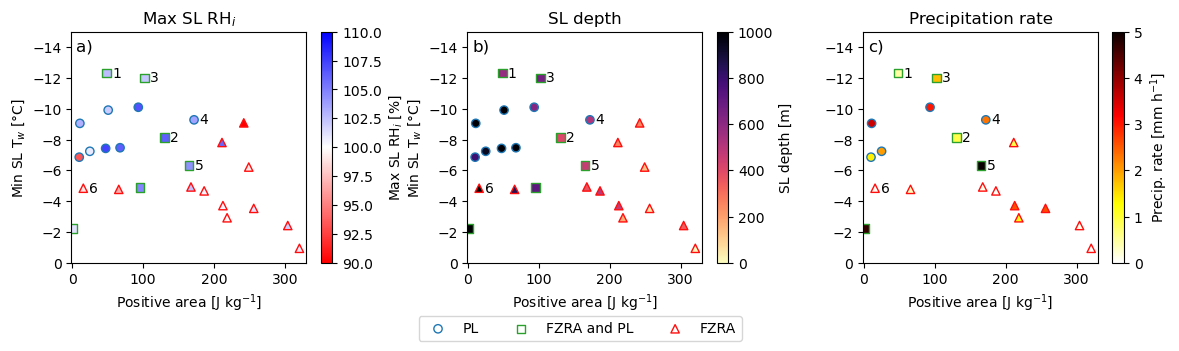

In [10]:
grav = 9.81
color_list = {'No precip.':'grey','PL':'#1f77b4','FZRA':"#ff0e0e",'FZRA and PL':'#2ca02c'}

fig,ax = plt.subplots(1,3,figsize=(14,3))

PA = np.linspace(0,330,1000)

# Left panel: precipitation rate
cmap = 'hot_r'

to_plot_pl = df_manobs[df_manobs['manobs_with_mix'] == 'PL']
ax[2].scatter(to_plot_pl['WL_integral']*grav/273.15,to_plot_pl['min_CL_temp'], edgecolors=color_list['PL'],marker='o',\
    c=to_plot_pl.pr,cmap=cmap,vmin=0,vmax=5)

to_plot_pl_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA and PL']
ax[2].scatter(to_plot_pl_fzra['WL_integral']*grav/273.15,to_plot_pl_fzra['min_CL_temp'], edgecolors=color_list['FZRA and PL'],marker='s',\
    c=to_plot_pl_fzra.pr,cmap=cmap,vmin=0,vmax=5)

to_plot_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA']
sc = ax[2].scatter(to_plot_fzra['WL_integral']*grav/273.15,to_plot_fzra['min_CL_temp'], edgecolors=color_list['FZRA'],marker='^',\
    c=to_plot_fzra.pr,cmap=cmap,vmin=0,vmax=5)


ax[2].set_xlabel('Positive area [J kg$^{-1}$]')
ax[1].set_ylabel(r'Min SL T$_w$ [°C]')
ax[2].set_title('Precipitation rate')
ax[2].set_ylim([0,-15])
ax[2].set_xlim([-1,330])

plt.colorbar(sc,ax=ax[2],label=r'Precip. rate [mm h$^{-1}$]')

# Middle panel: Max RH_i
to_plot_pl = df_manobs[df_manobs['manobs_with_mix'] == 'PL']
sc = ax[0].scatter(to_plot_pl['WL_integral']*grav/273.15,to_plot_pl['min_CL_temp'], edgecolors=color_list['PL'],label='PL',marker='o',\
    c=to_plot_pl.CL_max_rhi,cmap='bwr_r',vmin=90,vmax=110)

to_plot_pl_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA and PL']
ax[0].scatter(to_plot_pl_fzra['WL_integral']*grav/273.15,to_plot_pl_fzra['min_CL_temp'], edgecolors=color_list['FZRA and PL'],label='FZRA and PL',marker='s',\
    c=to_plot_pl_fzra.CL_max_rhi,cmap='bwr_r',vmin=90,vmax=110)

to_plot_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA']
ax[0].scatter(to_plot_fzra['WL_integral']*grav/273.15,to_plot_fzra['min_CL_temp'], edgecolors=color_list['FZRA'],label='FZRA',marker='^',\
    c=to_plot_fzra.CL_max_rhi,cmap='bwr_r',vmin=90,vmax=110)

ax[0].set_xlabel('Positive area [J kg$^{-1}$]')
ax[0].set_ylabel(r'Min SL T$_w$ [°C]')
ax[0].set_title(r'Max SL RH$_i$')
ax[0].set_ylim([0,-15])
ax[0].set_xlim([-1,330])

plt.colorbar(sc,ax=ax[0],label=r'Max SL RH$_i$ [%]')

# Right panel: SL depth
to_plot_pl = df_manobs[df_manobs['manobs_with_mix'] == 'PL']
sc = ax[1].scatter(to_plot_pl['WL_integral']*grav/273.15,to_plot_pl['min_CL_temp'], edgecolors=color_list['PL'],marker='o',\
    c=to_plot_pl.cl_depth_hght,cmap='magma_r',vmin=0,vmax=1000)

to_plot_pl_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA and PL']
ax[1].scatter(to_plot_pl_fzra['WL_integral']*grav/273.15,to_plot_pl_fzra['min_CL_temp'], edgecolors=color_list['FZRA and PL'],marker='s',\
    c=to_plot_pl_fzra.cl_depth_hght,cmap='magma_r',vmin=0,vmax=1000)

to_plot_fzra = df_manobs[df_manobs['manobs_with_mix'] == 'FZRA']
ax[1].scatter(to_plot_fzra['WL_integral']*grav/273.15,to_plot_fzra['min_CL_temp'], edgecolors=color_list['FZRA'],marker='^',\
    c=to_plot_fzra.cl_depth_hght,cmap='magma_r',vmin=0,vmax=1000)


ax[1].set_xlabel('Positive area [J kg$^{-1}$]')
ax[1].set_ylabel(r'Min SL T$_w$ [°C]')
ax[1].set_title('SL depth')
ax[1].set_ylim([0,-15])
ax[1].set_xlim([-1,330])

# For legend
ax[1].scatter(-10,-10, edgecolors=color_list['PL'],label='PL',marker='o',facecolor='none')
ax[1].scatter(-10,-10, edgecolors=color_list['FZRA and PL'],label='FZRA and PL',marker='s',facecolor='none')
ax[1].scatter(-10,-10, edgecolors=color_list['FZRA'],label='FZRA',marker='^',facecolor='none')


plt.colorbar(sc,ax=ax[1],label=r'SL depth [m]')

ax[0].text(0.02, 0.97, 'a)', transform=ax[0].transAxes, fontsize=12, va='top')
ax[1].text(0.02, 0.97, 'b)', transform=ax[1].transAxes, fontsize=12, va='top')
ax[2].text(0.02, 0.97, 'c)', transform=ax[2].transAxes, fontsize=12, va='top')

ax[1].legend(loc='upper right',bbox_to_anchor=(1.2,-0.2), ncol=3)

ax[0] = annotate_5_points_mintemp(ax[0], df_manobs)
ax[1] = annotate_5_points_mintemp(ax[1], df_manobs)
ax[2] = annotate_5_points_mintemp(ax[2], df_manobs)

plt.subplots_adjust(wspace=0.35)
# plt.savefig('figures/modZerr-like_3panels.png',format='png',dpi=200,bbox_inches='tight')

In [11]:
df_manobs_to_analyze = df_manobs[(df_manobs['manobs_with_mix'] == 'FZRA') & (df_manobs.CL_max_rhi>100) & (df_manobs.min_CL_temp<-4)]
df_manobs_to_analyze[['min_CL_temp','CL_max_rhi','manobs_with_mix','IOP','site','rounded_time']]

,min_CL_temp,CL_max_rhi,manobs_with_mix,IOP,site,rounded_time
825,-7.808827,106.014311,FZRA,IOP5,Gault,2022-02-22 22:30:00
1406,-4.921206,102.389433,FZRA,IOP5,Sorel,2022-02-23 04:20:00
1720,-4.665521,100.393214,FZRA,IOP8,Trois,2022-03-06 16:10:00
